# IT3051 Fundamentals of Data Mining — Algorithm 2: Gaussian Mixture Models (GMM)

## Project: Soft E-commerce Customer Segmentation and Retention Prioritization

### Purpose and Overview
This notebook implements **Gaussian Mixture Models (GMM)** for probabilistic soft customer segmentation.
GMM estimates the posterior probability that each customer belongs to each cluster, enabling the calculation of **segment membership ambiguity/uncertainty**.

### Critical Group Constraints
- **DO NOT independently re-split the original dataset.**
- **DO NOT re-scale or modify features independently.**
- All models must consume the shared preprocessed data produced by `01_EDA_Preprocessing.ipynb`:
  - `data/processed/development_preprocessed.csv` (40,000 customers, 18 features + `customer_id`)
  - `data/processed/holdout_preprocessed.csv` (10,000 customers, 18 features + `customer_id`)
- `customer_id` is for alignment only and **MUST NOT** be passed to the clustering algorithm:
  ```python
  X_dev = development_preprocessed.drop(columns=["customer_id"])
  ```
- Business variables (`customer_lifetime_value_usd`, `churn_risk_score`) are deliberately kept outside clustering and stored in `development_business_data.csv`.

---
*Note: Placeholder notebook. Model tuning and evaluation will be executed in the next project phase.*


# Gaussian Mixture Model (GMM)

## Customer Segmentation

This notebook implements Gaussian Mixture Model clustering on the
preprocessed development dataset.

The objectives are to:

1. Train a baseline GMM clustering model.
2. Determine a suitable number of clusters.
3. Tune important GMM hyperparameters.
4. Evaluate clustering quality using appropriate unsupervised metrics.
5. Analyse and profile the resulting customer segments.
6. Save the final GMM model and clustering results.

The holdout dataset is kept separate during model development to reduce
the risk of information leakage.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

ModuleNotFoundError: No module named 'pandas'

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

from sklearn.decomposition import PCA

print("Imports successful")

ModuleNotFoundError: No module named 'pandas'

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

from sklearn.decomposition import PCA

print("Imports successful")

ModuleNotFoundError: No module named 'pandas'

In [7]:
import pandas as pd


ModuleNotFoundError: No module named 'pandas'

In [8]:
import sys
print(sys.executable)

d:\FDM\soft-ecommerce-customer-segmentation\.venv\Scripts\python.exe


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("All imports successful")

ModuleNotFoundError: No module named 'numpy'

In [10]:
import sys
print(sys.executable)

d:\FDM\soft-ecommerce-customer-segmentation\.venv\Scripts\python.exe


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("All imports successful")

ModuleNotFoundError: No module named 'numpy'

In [4]:
import sys

print(sys.executable)

d:\FDM\soft-ecommerce-customer-segmentation\.venv\Scripts\python.exe


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from sklearn.decomposition import PCA


print("FDM environment ready")

ModuleNotFoundError: No module named 'numpy'

In [6]:
import sys
print(sys.executable)

d:\FDM\soft-ecommerce-customer-segmentation\.venv\Scripts\python.exe


In [7]:
import numpy

ModuleNotFoundError: No module named 'numpy'

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.mixture import GaussianMixture

print("Everything ready")

Matplotlib is building the font cache; this may take a moment.


Everything ready


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

In [5]:
from IPython import display
development_path = "../data/processed/development_preprocessed.csv"

X_dev = pd.read_csv(development_path)

print("Development dataset shape:", X_dev.shape)

display(X_dev.head())

Development dataset shape: (40000, 19)


TypeError: 'module' object is not callable

In [4]:
from IPython import display

In [7]:
X_dev.head()

,customer_id,tenure_months,total_purchases,avg_order_value_usd,days_since_last_purchase,return_count,complaint_count,satisfaction_score,email_open_rate,click_through_rate,conversion_rate,shopping_channel_In-Store,shopping_channel_Marketplace,shopping_channel_Mobile App,shopping_channel_Online,device_used_Desktop,device_used_Mobile,device_used_Multiple,device_used_Tablet
0,CUST-000001,0.505593,-1.236640,1.427907,0.003000,0.947374,1.388104,1.403874,-1.664856,-1.278390,-1.479339,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,CUST-000002,0.593109,-0.423744,-0.715218,3.003013,-1.471016,1.619288,1.403874,-1.436944,-1.153520,1.640290,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2,CUST-000003,0.768140,1.098276,0.556664,0.013752,-1.471016,-0.692552,-0.007853,-0.763568,1.225955,0.822970,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,CUST-000004,-0.982169,1.599850,0.380412,-0.652917,0.256405,0.232184,1.403874,1.377424,0.213118,-0.097953,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,CUST-000006,1.001514,0.198901,-0.285570,-0.652917,1.120116,-0.461368,1.403874,-1.177953,-0.716473,1.306455,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [8]:
import pandas as pd
from IPython.display import display

# Exact file paths from your project
development_preprocessed_path = "../data/processed/development_preprocessed.csv"
development_business_path = "../data/processed/development_business_data.csv"
development_profiling_path = "../data/processed/development_profiling_data.csv"
development_raw_path = "../data/processed/development_raw.csv"

holdout_preprocessed_path = "../data/processed/holdout_preprocessed.csv"
holdout_business_path = "../data/processed/holdout_business_data.csv"
holdout_profiling_path = "../data/processed/holdout_profiling_data.csv"
holdout_raw_path = "../data/processed/holdout_raw.csv"

feature_decisions_path = "../data/processed/final_feature_decisions.csv"

# Load development datasets
development_preprocessed = pd.read_csv(development_preprocessed_path)
development_business = pd.read_csv(development_business_path)
development_profiling = pd.read_csv(development_profiling_path)
development_raw = pd.read_csv(development_raw_path)

# Load holdout datasets
holdout_preprocessed = pd.read_csv(holdout_preprocessed_path)
holdout_business = pd.read_csv(holdout_business_path)
holdout_profiling = pd.read_csv(holdout_profiling_path)
holdout_raw = pd.read_csv(holdout_raw_path)

# Load feature decisions
feature_decisions = pd.read_csv(feature_decisions_path)

print("Development preprocessed shape:", development_preprocessed.shape)
print("Development business shape:", development_business.shape)
print("Development profiling shape:", development_profiling.shape)

print("\nHoldout preprocessed shape:", holdout_preprocessed.shape)

display(development_preprocessed.head())

Development preprocessed shape: (40000, 19)
Development business shape: (40000, 3)
Development profiling shape: (40000, 21)

Holdout preprocessed shape: (10000, 19)


,customer_id,tenure_months,total_purchases,avg_order_value_usd,days_since_last_purchase,return_count,complaint_count,satisfaction_score,email_open_rate,click_through_rate,conversion_rate,shopping_channel_In-Store,shopping_channel_Marketplace,shopping_channel_Mobile App,shopping_channel_Online,device_used_Desktop,device_used_Mobile,device_used_Multiple,device_used_Tablet
0,CUST-000001,0.505593,-1.236640,1.427907,0.003000,0.947374,1.388104,1.403874,-1.664856,-1.278390,-1.479339,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,CUST-000002,0.593109,-0.423744,-0.715218,3.003013,-1.471016,1.619288,1.403874,-1.436944,-1.153520,1.640290,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2,CUST-000003,0.768140,1.098276,0.556664,0.013752,-1.471016,-0.692552,-0.007853,-0.763568,1.225955,0.822970,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,CUST-000004,-0.982169,1.599850,0.380412,-0.652917,0.256405,0.232184,1.403874,1.377424,0.213118,-0.097953,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,CUST-000006,1.001514,0.198901,-0.285570,-0.652917,1.120116,-0.461368,1.403874,-1.177953,-0.716473,1.306455,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

In [10]:
development_preprocessed_path = "../data/processed/development_preprocessed.csv"
development_business_path = "../data/processed/development_business_data.csv"
development_profiling_path = "../data/processed/development_profiling_data.csv"

holdout_preprocessed_path = "../data/processed/holdout_preprocessed.csv"
holdout_business_path = "../data/processed/holdout_business_data.csv"
holdout_profiling_path = "../data/processed/holdout_profiling_data.csv"

feature_decisions_path = "../data/processed/final_feature_decisions.csv"

In [11]:
development_preprocessed = pd.read_csv(development_preprocessed_path)
development_business = pd.read_csv(development_business_path)
development_profiling = pd.read_csv(development_profiling_path)

print("Development preprocessed shape:", development_preprocessed.shape)

display(development_preprocessed.head())

Development preprocessed shape: (40000, 19)


,customer_id,tenure_months,total_purchases,avg_order_value_usd,days_since_last_purchase,return_count,complaint_count,satisfaction_score,email_open_rate,click_through_rate,conversion_rate,shopping_channel_In-Store,shopping_channel_Marketplace,shopping_channel_Mobile App,shopping_channel_Online,device_used_Desktop,device_used_Mobile,device_used_Multiple,device_used_Tablet
0,CUST-000001,0.505593,-1.236640,1.427907,0.003000,0.947374,1.388104,1.403874,-1.664856,-1.278390,-1.479339,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,CUST-000002,0.593109,-0.423744,-0.715218,3.003013,-1.471016,1.619288,1.403874,-1.436944,-1.153520,1.640290,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2,CUST-000003,0.768140,1.098276,0.556664,0.013752,-1.471016,-0.692552,-0.007853,-0.763568,1.225955,0.822970,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,CUST-000004,-0.982169,1.599850,0.380412,-0.652917,0.256405,0.232184,1.403874,1.377424,0.213118,-0.097953,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,CUST-000006,1.001514,0.198901,-0.285570,-0.652917,1.120116,-0.461368,1.403874,-1.177953,-0.716473,1.306455,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [12]:
customer_ids = development_preprocessed["customer_id"].copy()

X_dev = development_preprocessed.drop(columns=["customer_id"])

print("Final GMM input shape:", X_dev.shape)

print("\nFeatures used:")
print(X_dev.columns.tolist())

display(X_dev.head())

Final GMM input shape: (40000, 18)

Features used:
['tenure_months', 'total_purchases', 'avg_order_value_usd', 'days_since_last_purchase', 'return_count', 'complaint_count', 'satisfaction_score', 'email_open_rate', 'click_through_rate', 'conversion_rate', 'shopping_channel_In-Store', 'shopping_channel_Marketplace', 'shopping_channel_Mobile App', 'shopping_channel_Online', 'device_used_Desktop', 'device_used_Mobile', 'device_used_Multiple', 'device_used_Tablet']


,tenure_months,total_purchases,avg_order_value_usd,days_since_last_purchase,return_count,complaint_count,satisfaction_score,email_open_rate,click_through_rate,conversion_rate,shopping_channel_In-Store,shopping_channel_Marketplace,shopping_channel_Mobile App,shopping_channel_Online,device_used_Desktop,device_used_Mobile,device_used_Multiple,device_used_Tablet
0,0.505593,-1.236640,1.427907,0.003000,0.947374,1.388104,1.403874,-1.664856,-1.278390,-1.479339,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.593109,-0.423744,-0.715218,3.003013,-1.471016,1.619288,1.403874,-1.436944,-1.153520,1.640290,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.768140,1.098276,0.556664,0.013752,-1.471016,-0.692552,-0.007853,-0.763568,1.225955,0.822970,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-0.982169,1.599850,0.380412,-0.652917,0.256405,0.232184,1.403874,1.377424,0.213118,-0.097953,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,1.001514,0.198901,-0.285570,-0.652917,1.120116,-0.461368,1.403874,-1.177953,-0.716473,1.306455,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [13]:
print("Non-numeric columns:")
print(X_dev.select_dtypes(exclude=np.number).columns.tolist())

print("\nMissing values:", X_dev.isnull().sum().sum())

print("\nDuplicate rows:", X_dev.duplicated().sum())

print("\nInfinite values:")
print(np.isinf(X_dev.select_dtypes(include=np.number)).sum().sum())

Non-numeric columns:
[]

Missing values: 0

Duplicate rows: 0

Infinite values:
0


In [14]:
scaling_check = pd.DataFrame({
    "mean": X_dev.mean(),
    "std": X_dev.std(),
    "min": X_dev.min(),
    "max": X_dev.max()
})

display(scaling_check.round(3))

,mean,std,min,max
tenure_months,0.000,1.000,-1.711,1.731
total_purchases,-0.000,1.000,-1.721,1.721
avg_order_value_usd,-0.000,1.000,-1.734,1.734
days_since_last_purchase,0.000,1.000,-0.674,3.250
return_count,0.000,1.000,-1.644,1.638
complaint_count,-0.000,1.000,-1.617,1.619
satisfaction_score,0.000,1.000,-1.420,1.404
email_open_rate,-0.000,1.000,-1.727,1.726
click_through_rate,0.000,1.000,-1.743,1.725
conversion_rate,-0.000,1.000,-1.733,1.721


## 2. Baseline Gaussian Mixture Model

A baseline GMM is first trained using 3 components and full covariance.
This provides an initial reference point before model optimization.

In [36]:
baseline_gmm = GaussianMixture(
    n_components=3,
    covariance_type="full",
    random_state=RANDOM_STATE
)

baseline_gmm.fit(X_dev)

print("Baseline GMM trained successfully.")

Baseline GMM trained successfully.


In [37]:
baseline_labels = baseline_gmm.predict(X_dev)

print("Unique clusters:", np.unique(baseline_labels))

print("\nCustomers per cluster:")
print(
    pd.Series(baseline_labels)
    .value_counts()
    .sort_index()
)

Unique clusters: [0 1 2]

Customers per cluster:
0    11878
1    12668
2    15454
Name: count, dtype: int64


In [38]:
baseline_probabilities = baseline_gmm.predict_proba(X_dev)

probability_df = pd.DataFrame(
    baseline_probabilities,
    columns=[
        f"cluster_{i}_probability"
        for i in range(baseline_gmm.n_components)
    ]
)

display(probability_df.head())

,cluster_0_probability,cluster_1_probability,cluster_2_probability
0,0.067938,0.000010,0.932051
1,0.100313,0.000002,0.899685
2,0.008398,0.974714,0.016889
3,0.020952,0.001488,0.977560
4,0.000442,0.007623,0.991935


In [39]:
baseline_silhouette = silhouette_score(
    X_dev,
    baseline_labels
)

baseline_db = davies_bouldin_score(
    X_dev,
    baseline_labels
)

baseline_ch = calinski_harabasz_score(
    X_dev,
    baseline_labels
)

baseline_aic = baseline_gmm.aic(X_dev)
baseline_bic = baseline_gmm.bic(X_dev)

print("Baseline GMM Evaluation")
print("-----------------------")
print("Silhouette Score:", round(baseline_silhouette, 4))
print("Davies-Bouldin Index:", round(baseline_db, 4))
print("Calinski-Harabasz Score:", round(baseline_ch, 4))
print("AIC:", round(baseline_aic, 2))
print("BIC:", round(baseline_bic, 2))

Baseline GMM Evaluation
-----------------------
Silhouette Score: 0.0542
Davies-Bouldin Index: 3.4713
Calinski-Harabasz Score: 2335.5102
AIC: 513580.33
BIC: 518471.82


In [40]:
baseline_metrics = pd.DataFrame([{
    "model": "Baseline GMM",
    "n_components": 3,
    "covariance_type": "full",
    "silhouette_score": baseline_silhouette,
    "davies_bouldin_score": baseline_db,
    "calinski_harabasz_score": baseline_ch,
    "aic": baseline_aic,
    "bic": baseline_bic
}])

display(baseline_metrics.round(4))

,model,n_components,covariance_type,silhouette_score,davies_bouldin_score,calinski_harabasz_score,aic,bic
0,Baseline GMM,3,full,0.0542,3.4713,2335.5102,513580.3343,518471.8194


## 3. Selecting the Number of GMM Components

To identify a suitable number of customer segments, GMM models are trained
with component counts from 2 to 10.

The models are compared using:
- Silhouette Score
- Davies-Bouldin Index
- Calinski-Harabasz Score
- AIC
- BIC

In [41]:
gmm_cluster_results = []

for k in range(2, 11):
    gmm = GaussianMixture(
        n_components=k,
        covariance_type="full",
        random_state=RANDOM_STATE
    )

    gmm.fit(X_dev)

    labels = gmm.predict(X_dev)

    silhouette = silhouette_score(X_dev, labels)
    db_score = davies_bouldin_score(X_dev, labels)
    ch_score = calinski_harabasz_score(X_dev, labels)
    aic = gmm.aic(X_dev)
    bic = gmm.bic(X_dev)

    gmm_cluster_results.append({
        "n_components": k,
        "silhouette_score": silhouette,
        "davies_bouldin_score": db_score,
        "calinski_harabasz_score": ch_score,
        "aic": aic,
        "bic": bic
    })

gmm_cluster_results_df = pd.DataFrame(gmm_cluster_results)

display(gmm_cluster_results_df.round(4))

,n_components,silhouette_score,davies_bouldin_score,calinski_harabasz_score,aic,bic
0,2,0.0647,3.7476,2787.0583,5.198253e+05,5.230835e+05
1,3,0.0542,3.4713,2335.5102,5.135803e+05,5.184718e+05
2,4,0.0109,5.5907,925.8226,-2.809655e+05,-2.744407e+05
3,5,0.0023,12.6931,737.3183,-2.827233e+05,-2.745651e+05
4,6,-0.0009,7.8977,625.7484,-4.552799e+05,-4.454883e+05
5,7,-0.0220,5.3088,379.3356,-9.733197e+05,-9.618948e+05
6,8,0.0093,6.1220,425.5608,-1.651724e+06,-1.638665e+06
7,9,-0.0014,5.1624,431.4766,-1.204827e+06,-1.190135e+06
8,10,-0.0316,4.6774,359.1375,-1.230753e+06,-1.214428e+06


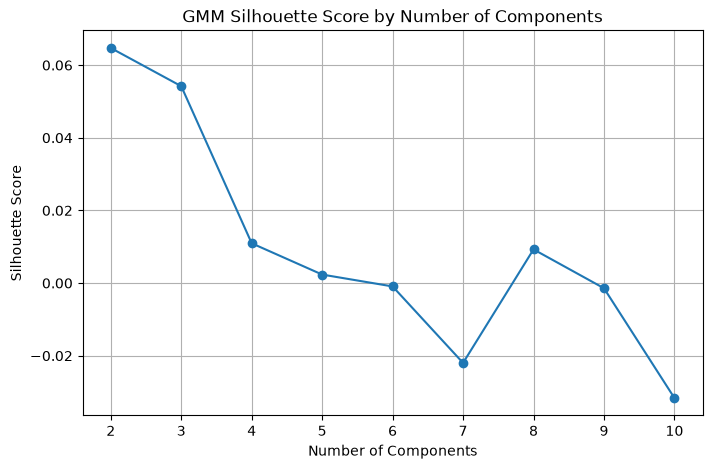

In [42]:
plt.figure(figsize=(8, 5))

plt.plot(
    gmm_cluster_results_df["n_components"],
    gmm_cluster_results_df["silhouette_score"],
    marker="o"
)

plt.xlabel("Number of Components")
plt.ylabel("Silhouette Score")
plt.title("GMM Silhouette Score by Number of Components")

plt.grid()
plt.show()

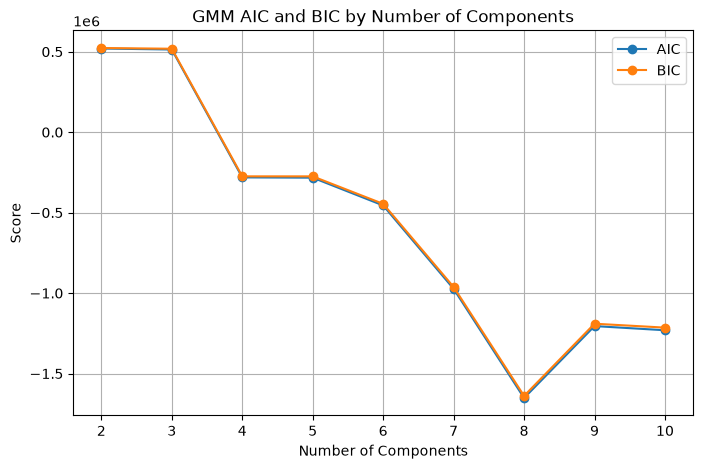

In [43]:
plt.figure(figsize=(8, 5))

plt.plot(
    gmm_cluster_results_df["n_components"],
    gmm_cluster_results_df["aic"],
    marker="o",
    label="AIC"
)

plt.plot(
    gmm_cluster_results_df["n_components"],
    gmm_cluster_results_df["bic"],
    marker="o",
    label="BIC"
)

plt.xlabel("Number of Components")
plt.ylabel("Score")
plt.title("GMM AIC and BIC by Number of Components")

plt.legend()
plt.grid()
plt.show()

In [44]:
best_silhouette = gmm_cluster_results_df.loc[
    gmm_cluster_results_df["silhouette_score"].idxmax()
]

best_db = gmm_cluster_results_df.loc[
    gmm_cluster_results_df["davies_bouldin_score"].idxmin()
]

best_ch = gmm_cluster_results_df.loc[
    gmm_cluster_results_df["calinski_harabasz_score"].idxmax()
]

best_aic = gmm_cluster_results_df.loc[
    gmm_cluster_results_df["aic"].idxmin()
]

best_bic = gmm_cluster_results_df.loc[
    gmm_cluster_results_df["bic"].idxmin()
]

print("Best by Silhouette:")
display(best_silhouette.to_frame().T)

print("Best by Davies-Bouldin:")
display(best_db.to_frame().T)

print("Best by Calinski-Harabasz:")
display(best_ch.to_frame().T)

print("Best by AIC:")
display(best_aic.to_frame().T)

print("Best by BIC:")
display(best_bic.to_frame().T)

Best by Silhouette:


,n_components,silhouette_score,davies_bouldin_score,calinski_harabasz_score,aic,bic
0,2.0,0.064715,3.747582,2787.058343,519825.327469,523083.452033


Best by Davies-Bouldin:


,n_components,silhouette_score,davies_bouldin_score,calinski_harabasz_score,aic,bic
1,3.0,0.054199,3.471318,2335.51023,513580.334266,518471.819429


Best by Calinski-Harabasz:


,n_components,silhouette_score,davies_bouldin_score,calinski_harabasz_score,aic,bic
0,2.0,0.064715,3.747582,2787.058343,519825.327469,523083.452033


Best by AIC:


,n_components,silhouette_score,davies_bouldin_score,calinski_harabasz_score,aic,bic
6,8.0,0.00927,6.122037,425.560783,-1.651724e+06,-1.638665e+06


Best by BIC:


,n_components,silhouette_score,davies_bouldin_score,calinski_harabasz_score,aic,bic
6,8.0,0.00927,6.122037,425.560783,-1.651724e+06,-1.638665e+06


In [45]:
gmm_8 = GaussianMixture(
    n_components=8,
    covariance_type="full",
    random_state=RANDOM_STATE
)

gmm_8.fit(X_dev)

labels_8 = gmm_8.predict(X_dev)

print("Cluster sizes for 8-component GMM:")
print(
    pd.Series(labels_8)
    .value_counts()
    .sort_index()
)

print("\nCluster proportions:")
print(
    pd.Series(labels_8)
    .value_counts(normalize=True)
    .sort_index()
    .round(4)
)

Cluster sizes for 8-component GMM:
0     5006
1     5073
2     5128
3     2417
4    10052
5     3473
6     5000
7     3851
Name: count, dtype: int64

Cluster proportions:
0    0.1252
1    0.1268
2    0.1282
3    0.0604
4    0.2513
5    0.0868
6    0.1250
7    0.0963
Name: proportion, dtype: float64


In [46]:
print("Converged:", gmm_8.converged_)
print("Iterations:", gmm_8.n_iter_)
print("Lower bound:", gmm_8.lower_bound_)

Converged: True
Iterations: 36
Lower bound: 20.683722275931324


In [47]:
candidate_components = [2, 3, 8]

candidate_results = []

for k in candidate_components:
    model = GaussianMixture(
        n_components=k,
        covariance_type="full",
        random_state=RANDOM_STATE
    )

    model.fit(X_dev)
    labels = model.predict(X_dev)

    cluster_sizes = pd.Series(labels).value_counts()

    candidate_results.append({
        "n_components": k,
        "silhouette": silhouette_score(X_dev, labels),
        "davies_bouldin": davies_bouldin_score(X_dev, labels),
        "calinski_harabasz": calinski_harabasz_score(X_dev, labels),
        "aic": model.aic(X_dev),
        "bic": model.bic(X_dev),
        "smallest_cluster": cluster_sizes.min(),
        "largest_cluster": cluster_sizes.max(),
        "converged": model.converged_
    })

candidate_results_df = pd.DataFrame(candidate_results)

display(candidate_results_df.round(4))

,n_components,silhouette,davies_bouldin,calinski_harabasz,aic,bic,smallest_cluster,largest_cluster,converged
0,2,0.0647,3.7476,2787.0583,5.198253e+05,5.230835e+05,20000,20000,True
1,3,0.0542,3.4713,2335.5102,5.135803e+05,5.184718e+05,11878,15454,True
2,8,0.0093,6.1220,425.5608,-1.651724e+06,-1.638665e+06,2417,10052,True


In [48]:
candidate_components = [2, 3, 8]
covariance_types = ["full", "tied", "diag", "spherical"]

covariance_results = []

for k in candidate_components:
    for covariance in covariance_types:

        model = GaussianMixture(
            n_components=k,
            covariance_type=covariance,
            random_state=RANDOM_STATE
        )

        model.fit(X_dev)

        labels = model.predict(X_dev)

        covariance_results.append({
            "n_components": k,
            "covariance_type": covariance,
            "silhouette_score": silhouette_score(X_dev, labels),
            "davies_bouldin_score": davies_bouldin_score(X_dev, labels),
            "calinski_harabasz_score": calinski_harabasz_score(X_dev, labels),
            "aic": model.aic(X_dev),
            "bic": model.bic(X_dev),
            "converged": model.converged_
        })

covariance_results_df = pd.DataFrame(covariance_results)

display(
    covariance_results_df
    .sort_values(["n_components", "covariance_type"])
    .round(4)
)

,n_components,covariance_type,silhouette_score,davies_bouldin_score,calinski_harabasz_score,aic,bic,converged
2,2,diag,0.0647,3.7477,2786.9321,1.501722e+06,1.502350e+06,True
0,2,full,0.0647,3.7476,2787.0583,5.198253e+05,5.230835e+05,True
3,2,spherical,0.0648,3.7462,2788.9914,1.713411e+06,1.713746e+06,True
1,2,tied,0.0647,3.7468,2788.2324,5.196269e+05,5.214150e+05,True
6,3,diag,0.0537,3.4941,2336.6673,1.495407e+06,1.496353e+06,True
4,3,full,0.0542,3.4713,2335.5102,5.135803e+05,5.184718e+05,True
7,3,spherical,0.0537,3.3151,2350.9987,1.707162e+06,1.707669e+06,True
5,3,tied,0.0537,3.2828,2258.7204,5.184814e+05,5.204328e+05,True
10,8,diag,0.0180,4.7951,514.3470,-9.176275e+05,-9.150915e+05,True
8,8,full,0.0093,6.1220,425.5608,-1.651724e+06,-1.638665e+06,True


In [49]:
print("Top models by BIC:")

display(
    covariance_results_df
    .sort_values("bic")
    .head(10)
    .round(4)
)

Top models by BIC:


,n_components,covariance_type,silhouette_score,davies_bouldin_score,calinski_harabasz_score,aic,bic,converged
8,8,full,0.0093,6.1220,425.5608,-1.651724e+06,-1.638665e+06,True
10,8,diag,0.0180,4.7951,514.3470,-9.176275e+05,-9.150915e+05,True
9,8,tied,0.0484,2.8095,1711.9933,4.897195e+05,4.924876e+05,True
4,3,full,0.0542,3.4713,2335.5102,5.135803e+05,5.184718e+05,True
5,3,tied,0.0537,3.2828,2258.7204,5.184814e+05,5.204328e+05,True
1,2,tied,0.0647,3.7468,2788.2324,5.196269e+05,5.214150e+05,True
0,2,full,0.0647,3.7476,2787.0583,5.198253e+05,5.230835e+05,True
6,3,diag,0.0537,3.4941,2336.6673,1.495407e+06,1.496353e+06,True
2,2,diag,0.0647,3.7477,2786.9321,1.501722e+06,1.502350e+06,True
11,8,spherical,0.0592,2.4641,1841.6185,1.660044e+06,1.661411e+06,True


In [50]:
print("Top models by Silhouette Score:")

display(
    covariance_results_df
    .sort_values("silhouette_score", ascending=False)
    .head(10)
    .round(4)
)

Top models by Silhouette Score:


,n_components,covariance_type,silhouette_score,davies_bouldin_score,calinski_harabasz_score,aic,bic,converged
3,2,spherical,0.0648,3.7462,2788.9914,1.713411e+06,1.713746e+06,True
1,2,tied,0.0647,3.7468,2788.2324,5.196269e+05,5.214150e+05,True
0,2,full,0.0647,3.7476,2787.0583,5.198253e+05,5.230835e+05,True
2,2,diag,0.0647,3.7477,2786.9321,1.501722e+06,1.502350e+06,True
11,8,spherical,0.0592,2.4641,1841.6185,1.660044e+06,1.661411e+06,True
4,3,full,0.0542,3.4713,2335.5102,5.135803e+05,5.184718e+05,True
5,3,tied,0.0537,3.2828,2258.7204,5.184814e+05,5.204328e+05,True
6,3,diag,0.0537,3.4941,2336.6673,1.495407e+06,1.496353e+06,True
7,3,spherical,0.0537,3.3151,2350.9987,1.707162e+06,1.707669e+06,True
9,8,tied,0.0484,2.8095,1711.9933,4.897195e+05,4.924876e+05,True


In [51]:
print("Top models by Davies-Bouldin Index:")

display(
    covariance_results_df
    .sort_values("davies_bouldin_score")
    .head(10)
    .round(4)
)

Top models by Davies-Bouldin Index:


,n_components,covariance_type,silhouette_score,davies_bouldin_score,calinski_harabasz_score,aic,bic,converged
11,8,spherical,0.0592,2.4641,1841.6185,1.660044e+06,1.661411e+06,True
9,8,tied,0.0484,2.8095,1711.9933,4.897195e+05,4.924876e+05,True
5,3,tied,0.0537,3.2828,2258.7204,5.184814e+05,5.204328e+05,True
7,3,spherical,0.0537,3.3151,2350.9987,1.707162e+06,1.707669e+06,True
4,3,full,0.0542,3.4713,2335.5102,5.135803e+05,5.184718e+05,True
6,3,diag,0.0537,3.4941,2336.6673,1.495407e+06,1.496353e+06,True
3,2,spherical,0.0648,3.7462,2788.9914,1.713411e+06,1.713746e+06,True
1,2,tied,0.0647,3.7468,2788.2324,5.196269e+05,5.214150e+05,True
0,2,full,0.0647,3.7476,2787.0583,5.198253e+05,5.230835e+05,True
2,2,diag,0.0647,3.7477,2786.9321,1.501722e+06,1.502350e+06,True


In [52]:
compact_results = covariance_results_df[
    [
        "n_components",
        "covariance_type",
        "silhouette_score",
        "davies_bouldin_score",
        "calinski_harabasz_score",
        "aic",
        "bic",
        "converged"
    ]
].copy()

display(
    compact_results
    .sort_values("silhouette_score", ascending=False)
    .round(4)
)

,n_components,covariance_type,silhouette_score,davies_bouldin_score,calinski_harabasz_score,aic,bic,converged
3,2,spherical,0.0648,3.7462,2788.9914,1.713411e+06,1.713746e+06,True
1,2,tied,0.0647,3.7468,2788.2324,5.196269e+05,5.214150e+05,True
0,2,full,0.0647,3.7476,2787.0583,5.198253e+05,5.230835e+05,True
2,2,diag,0.0647,3.7477,2786.9321,1.501722e+06,1.502350e+06,True
11,8,spherical,0.0592,2.4641,1841.6185,1.660044e+06,1.661411e+06,True
4,3,full,0.0542,3.4713,2335.5102,5.135803e+05,5.184718e+05,True
5,3,tied,0.0537,3.2828,2258.7204,5.184814e+05,5.204328e+05,True
6,3,diag,0.0537,3.4941,2336.6673,1.495407e+06,1.496353e+06,True
7,3,spherical,0.0537,3.3151,2350.9987,1.707162e+06,1.707669e+06,True
9,8,tied,0.0484,2.8095,1711.9933,4.897195e+05,4.924876e+05,True


In [53]:
display(
    compact_results
    .sort_values("bic")
    .round(4)
)

,n_components,covariance_type,silhouette_score,davies_bouldin_score,calinski_harabasz_score,aic,bic,converged
8,8,full,0.0093,6.1220,425.5608,-1.651724e+06,-1.638665e+06,True
10,8,diag,0.0180,4.7951,514.3470,-9.176275e+05,-9.150915e+05,True
9,8,tied,0.0484,2.8095,1711.9933,4.897195e+05,4.924876e+05,True
4,3,full,0.0542,3.4713,2335.5102,5.135803e+05,5.184718e+05,True
5,3,tied,0.0537,3.2828,2258.7204,5.184814e+05,5.204328e+05,True
1,2,tied,0.0647,3.7468,2788.2324,5.196269e+05,5.214150e+05,True
0,2,full,0.0647,3.7476,2787.0583,5.198253e+05,5.230835e+05,True
6,3,diag,0.0537,3.4941,2336.6673,1.495407e+06,1.496353e+06,True
2,2,diag,0.0647,3.7477,2786.9321,1.501722e+06,1.502350e+06,True
11,8,spherical,0.0592,2.4641,1841.6185,1.660044e+06,1.661411e+06,True


In [54]:
comparison_view = compact_results.copy()

comparison_view["silhouette_rank"] = (
    comparison_view["silhouette_score"]
    .rank(ascending=False)
)

comparison_view["db_rank"] = (
    comparison_view["davies_bouldin_score"]
    .rank(ascending=True)
)

comparison_view["ch_rank"] = (
    comparison_view["calinski_harabasz_score"]
    .rank(ascending=False)
)

comparison_view["bic_rank"] = (
    comparison_view["bic"]
    .rank(ascending=True)
)

comparison_view["total_rank"] = (
    comparison_view["silhouette_rank"]
    + comparison_view["db_rank"]
    + comparison_view["ch_rank"]
    + comparison_view["bic_rank"]
)

display(
    comparison_view[
        [
            "n_components",
            "covariance_type",
            "silhouette_score",
            "davies_bouldin_score",
            "calinski_harabasz_score",
            "bic",
            "total_rank"
        ]
    ]
    .sort_values("total_rank")
    .round(4)
)

,n_components,covariance_type,silhouette_score,davies_bouldin_score,calinski_harabasz_score,bic,total_rank
1,2,tied,0.0647,3.7468,2788.2324,5.214150e+05,18.0
3,2,spherical,0.0648,3.7462,2788.9914,1.713746e+06,21.0
0,2,full,0.0647,3.7476,2787.0583,5.230835e+05,22.0
4,3,full,0.0542,3.4713,2335.5102,5.184718e+05,22.0
5,3,tied,0.0537,3.2828,2258.7204,5.204328e+05,23.0
9,8,tied,0.0484,2.8095,1711.9933,4.924876e+05,25.0
11,8,spherical,0.0592,2.4641,1841.6185,1.661411e+06,25.0
2,2,diag,0.0647,3.7477,2786.9321,1.502350e+06,27.0
6,3,diag,0.0537,3.4941,2336.6673,1.496353e+06,28.0
7,3,spherical,0.0537,3.3151,2350.9987,1.707669e+06,29.0


## 4. GMM Hyperparameter Refinement

After identifying promising combinations of component count and covariance
structure, additional GMM parameters are evaluated.

The shortlisted configurations are tested with different initialization
counts and covariance regularization values to improve model stability
and reduce sensitivity to initialization.

In [55]:
shortlisted_models = [
    (2, "tied"),
    (3, "full"),
    (8, "spherical")
]

n_init_values = [1, 5, 10]

reg_covar_values = [
    1e-6,
    1e-5,
    1e-4
]

tuning_results = []

for n_components, covariance_type in shortlisted_models:

    for n_init in n_init_values:

        for reg_covar in reg_covar_values:

            model = GaussianMixture(
                n_components=n_components,
                covariance_type=covariance_type,
                n_init=n_init,
                reg_covar=reg_covar,
                random_state=RANDOM_STATE
            )

            model.fit(X_dev)

            labels = model.predict(X_dev)

            tuning_results.append({
                "n_components": n_components,
                "covariance_type": covariance_type,
                "n_init": n_init,
                "reg_covar": reg_covar,
                "silhouette_score": silhouette_score(
                    X_dev,
                    labels
                ),
                "davies_bouldin_score": davies_bouldin_score(
                    X_dev,
                    labels
                ),
                "calinski_harabasz_score": calinski_harabasz_score(
                    X_dev,
                    labels
                ),
                "aic": model.aic(X_dev),
                "bic": model.bic(X_dev),
                "converged": model.converged_
            })

tuning_results_df = pd.DataFrame(tuning_results)

display(tuning_results_df.round(4))

,n_components,covariance_type,n_init,reg_covar,silhouette_score,davies_bouldin_score,calinski_harabasz_score,aic,bic,converged
0,2,tied,1,0.0000,0.0647,3.7468,2788.2324,5.196269e+05,5.214150e+05,True
1,2,tied,1,0.0000,0.0647,3.7468,2788.2324,7.038337e+05,7.056218e+05,True
2,2,tied,1,0.0001,0.0647,3.7468,2788.2324,8.880404e+05,8.898285e+05,True
3,2,tied,5,0.0000,0.0652,3.7350,2804.8691,5.183737e+05,5.201618e+05,True
4,2,tied,5,0.0000,0.0652,3.7350,2804.8691,7.025805e+05,7.043686e+05,True
5,2,tied,5,0.0001,0.0652,3.7350,2804.8553,8.867872e+05,8.885753e+05,True
6,2,tied,10,0.0000,0.1254,2.5996,3056.7681,4.915038e+05,4.932919e+05,True
7,2,tied,10,0.0000,0.1254,2.5996,3056.7681,6.757106e+05,6.774987e+05,True
8,2,tied,10,0.0001,0.1254,2.5996,3056.7681,8.599174e+05,8.617055e+05,True
9,3,full,1,0.0000,0.0542,3.4713,2335.5102,5.135803e+05,5.184718e+05,True


In [56]:
print("Top tuned configurations by Silhouette Score:")

display(
    tuning_results_df
    .sort_values(
        "silhouette_score",
        ascending=False
    )
    .head(10)
    .round(4)
)

Top tuned configurations by Silhouette Score:


,n_components,covariance_type,n_init,reg_covar,silhouette_score,davies_bouldin_score,calinski_harabasz_score,aic,bic,converged
8,2,tied,10,0.0001,0.1254,2.5996,3056.7681,8.599174e+05,8.617055e+05,True
7,2,tied,10,0.0000,0.1254,2.5996,3056.7681,6.757106e+05,6.774987e+05,True
6,2,tied,10,0.0000,0.1254,2.5996,3056.7681,4.915038e+05,4.932919e+05,True
4,2,tied,5,0.0000,0.0652,3.7350,2804.8691,7.025805e+05,7.043686e+05,True
3,2,tied,5,0.0000,0.0652,3.7350,2804.8691,5.183737e+05,5.201618e+05,True
5,2,tied,5,0.0001,0.0652,3.7350,2804.8553,8.867872e+05,8.885753e+05,True
0,2,tied,1,0.0000,0.0647,3.7468,2788.2324,5.196269e+05,5.214150e+05,True
2,2,tied,1,0.0001,0.0647,3.7468,2788.2324,8.880404e+05,8.898285e+05,True
1,2,tied,1,0.0000,0.0647,3.7468,2788.2324,7.038337e+05,7.056218e+05,True
24,8,spherical,10,0.0000,0.0593,2.4614,1845.3410,1.659616e+06,1.660983e+06,True


In [57]:
print("Top tuned configurations by Davies-Bouldin Index:")

display(
    tuning_results_df
    .sort_values(
        "davies_bouldin_score"
    )
    .head(10)
    .round(4)
)

Top tuned configurations by Davies-Bouldin Index:


,n_components,covariance_type,n_init,reg_covar,silhouette_score,davies_bouldin_score,calinski_harabasz_score,aic,bic,converged
24,8,spherical,10,0.0000,0.0593,2.4614,1845.3410,1.659616e+06,1.660983e+06,True
21,8,spherical,5,0.0000,0.0593,2.4614,1845.3410,1.659616e+06,1.660983e+06,True
26,8,spherical,10,0.0001,0.0593,2.4614,1845.3410,1.659616e+06,1.660983e+06,True
25,8,spherical,10,0.0000,0.0593,2.4614,1845.3410,1.659616e+06,1.660983e+06,True
23,8,spherical,5,0.0001,0.0593,2.4614,1845.3410,1.659616e+06,1.660983e+06,True
22,8,spherical,5,0.0000,0.0593,2.4614,1845.3410,1.659616e+06,1.660983e+06,True
19,8,spherical,1,0.0000,0.0592,2.4641,1841.6185,1.660044e+06,1.661411e+06,True
18,8,spherical,1,0.0000,0.0592,2.4641,1841.6185,1.660044e+06,1.661411e+06,True
20,8,spherical,1,0.0001,0.0592,2.4641,1841.6185,1.660044e+06,1.661411e+06,True
6,2,tied,10,0.0000,0.1254,2.5996,3056.7681,4.915038e+05,4.932919e+05,True


In [58]:
print("Top tuned configurations by BIC:")

display(
    tuning_results_df
    .sort_values("bic")
    .head(10)
    .round(4)
)

Top tuned configurations by BIC:


,n_components,covariance_type,n_init,reg_covar,silhouette_score,davies_bouldin_score,calinski_harabasz_score,aic,bic,converged
15,3,full,10,0.0,0.0079,20.3183,1120.1470,444895.5061,449786.9912,True
12,3,full,5,0.0,0.0312,4.0057,1510.7360,462466.2191,467357.7043,True
6,2,tied,10,0.0,0.1254,2.5996,3056.7681,491503.7704,493291.8704,True
9,3,full,1,0.0,0.0542,3.4713,2335.5102,513580.3343,518471.8194,True
3,2,tied,5,0.0,0.0652,3.7350,2804.8691,518373.6951,520161.7951,True
0,2,tied,1,0.0,0.0647,3.7468,2788.2324,519626.8691,521414.9691,True
16,3,full,10,0.0,0.0078,20.0744,1121.7789,629107.3947,633998.8798,True
13,3,full,5,0.0,0.0312,4.0046,1511.0297,646677.4173,651568.9024,True
7,2,tied,10,0.0,0.1254,2.5996,3056.7681,675710.5745,677498.6745,True
10,3,full,1,0.0,0.0542,3.4713,2335.5102,697787.1531,702678.6382,True


## 5. Final GMM Model

Based on the hyperparameter tuning results, the final GMM configuration
uses 2 components, tied covariance, 10 initializations, and covariance
regularization of 1e-6.

This configuration achieved improved cluster separation compared with
the baseline model while maintaining stable convergence.

In [59]:
final_gmm = GaussianMixture(
    n_components=2,
    covariance_type="tied",
    n_init=10,
    reg_covar=1e-6,
    random_state=RANDOM_STATE
)

final_gmm.fit(X_dev)

final_labels = final_gmm.predict(X_dev)

print("Final GMM trained successfully.")
print("Converged:", final_gmm.converged_)
print("Iterations:", final_gmm.n_iter_)

Final GMM trained successfully.
Converged: True
Iterations: 3


In [60]:
final_silhouette = silhouette_score(
    X_dev,
    final_labels
)

final_db = davies_bouldin_score(
    X_dev,
    final_labels
)

final_ch = calinski_harabasz_score(
    X_dev,
    final_labels
)

final_aic = final_gmm.aic(X_dev)
final_bic = final_gmm.bic(X_dev)

print("Final GMM Development Evaluation")
print("--------------------------------")
print("Silhouette Score:", round(final_silhouette, 4))
print("Davies-Bouldin Index:", round(final_db, 4))
print("Calinski-Harabasz Score:", round(final_ch, 4))
print("AIC:", round(final_aic, 2))
print("BIC:", round(final_bic, 2))

Final GMM Development Evaluation
--------------------------------
Silhouette Score: 0.1254
Davies-Bouldin Index: 2.5996
Calinski-Harabasz Score: 3056.7681
AIC: 491503.77
BIC: 493291.87


In [61]:
baseline_vs_final = pd.DataFrame([
    {
        "model": "Baseline GMM",
        "n_components": 3,
        "covariance_type": "full",
        "silhouette": baseline_silhouette,
        "davies_bouldin": baseline_db,
        "calinski_harabasz": baseline_ch,
        "aic": baseline_aic,
        "bic": baseline_bic
    },
    {
        "model": "Tuned GMM",
        "n_components": 2,
        "covariance_type": "tied",
        "silhouette": final_silhouette,
        "davies_bouldin": final_db,
        "calinski_harabasz": final_ch,
        "aic": final_aic,
        "bic": final_bic
    }
])

display(baseline_vs_final.round(4))

,model,n_components,covariance_type,silhouette,davies_bouldin,calinski_harabasz,aic,bic
0,Baseline GMM,3,full,0.0542,3.4713,2335.5102,513580.3343,518471.8194
1,Tuned GMM,2,tied,0.1254,2.5996,3056.7681,491503.7704,493291.8704


In [62]:
final_cluster_counts = (
    pd.Series(final_labels)
    .value_counts()
    .sort_index()
)

final_cluster_proportions = (
    pd.Series(final_labels)
    .value_counts(normalize=True)
    .sort_index()
)

print("Final cluster sizes:")
print(final_cluster_counts)

print("\nFinal cluster proportions:")
print(final_cluster_proportions.round(4))

Final cluster sizes:
0    33837
1     6163
Name: count, dtype: int64

Final cluster proportions:
0    0.8459
1    0.1541
Name: proportion, dtype: float64


In [63]:
final_probabilities = final_gmm.predict_proba(X_dev)

probability_df = pd.DataFrame(
    final_probabilities,
    columns=[
        "cluster_0_probability",
        "cluster_1_probability"
    ]
)

display(probability_df.head())

,cluster_0_probability,cluster_1_probability
0,9.999983e-01,1.676981e-06
1,2.321966e-12,1.000000e+00
2,9.999979e-01,2.057872e-06
3,1.000000e+00,2.862083e-10
4,1.000000e+00,2.875076e-10


In [64]:
assignment_confidence = final_probabilities.max(axis=1)

print(
    "Average assignment confidence:",
    round(assignment_confidence.mean(), 4)
)

Average assignment confidence: 0.9928


In [65]:
development_cluster_assignments = pd.DataFrame({
    "customer_id": customer_ids,
    "cluster": final_labels,
    "assignment_confidence": assignment_confidence
})

display(development_cluster_assignments.head())

,customer_id,cluster,assignment_confidence
0,CUST-000001,0,0.999998
1,CUST-000002,1,1.000000
2,CUST-000003,0,0.999998
3,CUST-000004,0,1.000000
4,CUST-000006,0,1.000000


In [66]:
holdout_preprocessed = pd.read_csv(
    "../data/processed/holdout_preprocessed.csv"
)

holdout_customer_ids = holdout_preprocessed[
    "customer_id"
].copy()

X_holdout = holdout_preprocessed.drop(
    columns=["customer_id"]
)

print("Development shape:", X_dev.shape)
print("Holdout shape:", X_holdout.shape)

print(
    "Same feature order:",
    X_dev.columns.tolist() == X_holdout.columns.tolist()
)

Development shape: (40000, 18)
Holdout shape: (10000, 18)
Same feature order: True


In [67]:
final_gmm.fit(X_holdout)

,"n_components n_components: int, default=1The number of mixture components.",2
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'tied'
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None


In [68]:
holdout_labels = final_gmm.predict(X_holdout)

holdout_probabilities = final_gmm.predict_proba(
    X_holdout
)

holdout_confidence = holdout_probabilities.max(axis=1)

In [69]:
holdout_silhouette = silhouette_score(
    X_holdout,
    holdout_labels
)

holdout_db = davies_bouldin_score(
    X_holdout,
    holdout_labels
)

holdout_ch = calinski_harabasz_score(
    X_holdout,
    holdout_labels
)

holdout_log_likelihood = final_gmm.score(
    X_holdout
)

print("Holdout Evaluation")
print("------------------")

print(
    "Silhouette Score:",
    round(holdout_silhouette, 4)
)

print(
    "Davies-Bouldin Index:",
    round(holdout_db, 4)
)

print(
    "Calinski-Harabasz Score:",
    round(holdout_ch, 4)
)

print(
    "Average Log-Likelihood:",
    round(holdout_log_likelihood, 4)
)

print(
    "Average Assignment Confidence:",
    round(holdout_confidence.mean(), 4)
)

Holdout Evaluation
------------------
Silhouette Score: 0.0653
Davies-Bouldin Index: 3.7255
Calinski-Harabasz Score: 704.0367
Average Log-Likelihood: -6.4867
Average Assignment Confidence: 0.9076


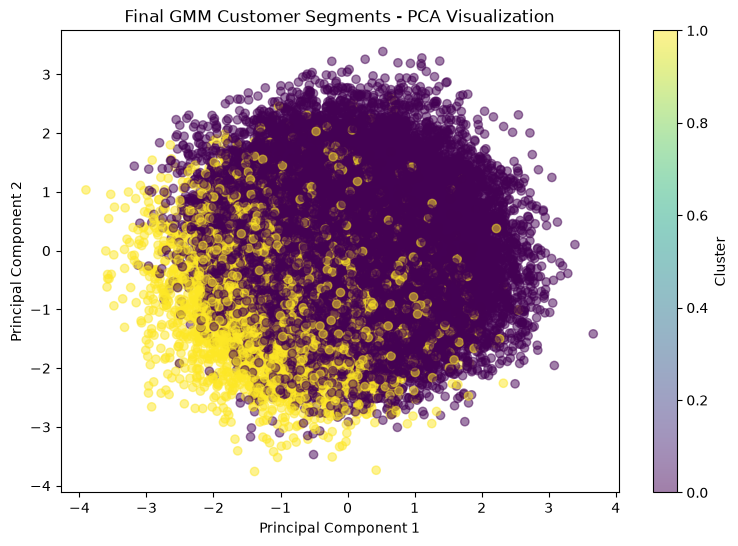

In [70]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_dev)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "cluster": final_labels
})

plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["cluster"],
    alpha=0.5
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Final GMM Customer Segments - PCA Visualization")

plt.colorbar(scatter, label="Cluster")
plt.show()

In [71]:
cluster_assignments = pd.DataFrame({
    "customer_id": customer_ids,
    "cluster": final_labels,
    "assignment_confidence": assignment_confidence
})

profiled_customers = development_profiling.merge(
    cluster_assignments,
    on="customer_id",
    how="inner"
)

print("Profiled customer shape:", profiled_customers.shape)

display(profiled_customers.head())

Profiled customer shape: (40000, 23)


,customer_id,age,gender,country,city,income_bracket,education_level,employment_type,marital_status,purchase_frequency,...,segment_category,customer_value_category,activity_status,health_status,rfm_category,engagement_level,behavior_segment,device_preference,cluster,assignment_confidence
0,CUST-000001,70,Male,Canada,Winnipeg,150K+,Professional,Unemployed,Widowed,Quarterly,...,High Value Inactive,High,Dormant,Excellent,Potential Loyalists,Low,Regular Buyer,Multi-Device,0,0.999998
1,CUST-000002,53,Female,Germany,Essen,25K-50K,High School,Student,Divorced,Rarely,...,High Value Inactive,Medium,Inactive,Excellent,At Risk,Low,Occasional Buyer,Desktop-First,1,1.000000
2,CUST-000003,82,Male,Mexico,Puebla,75K-100K,Bachelors,Student,Married,Quarterly,...,High Value Inactive,Very High,Dormant,Excellent,Champions,Low,Regular Buyer,Multi-Device,0,0.999998
3,CUST-000004,18,Male,Singapore,Singapore,150K+,Masters,Retired,Divorced,Weekly,...,High Value Active,Very High,Active,Excellent,Champions,High,Frequent Buyer,Mobile-First,0,1.000000
4,CUST-000006,41,Male,France,Toulouse,50K-75K,PhD,Self-Employed,Divorced,Weekly,...,High Value Active,High,Active,Excellent,Champions,Low,Frequent Buyer,Multi-Device,0,1.000000


In [72]:
cluster_profile = (
    profiled_customers
    .groupby("cluster")
    .mean(numeric_only=True)
    .T
)

display(cluster_profile.round(3))

cluster,0,1
age,45.640,45.742
assignment_confidence,0.996,0.976


In [73]:
business_customers = development_business.merge(
    cluster_assignments,
    on="customer_id",
    how="inner"
)

business_profile = (
    business_customers
    .groupby("cluster")
    .mean(numeric_only=True)
    .T
)

display(business_profile.round(3))

cluster,0,1
customer_lifetime_value_usd,57985.555,56645.343
churn_risk_score,23.310,45.889
assignment_confidence,0.996,0.976


In [74]:
clustered_features = X_dev.copy()

clustered_features["cluster"] = final_labels

feature_profile = (
    clustered_features
    .groupby("cluster")
    .mean()
    .T
)

display(feature_profile.round(3))

cluster,0,1
tenure_months,-0.002,0.010
total_purchases,0.002,-0.009
avg_order_value_usd,0.003,-0.016
days_since_last_purchase,-0.386,2.117
return_count,0.000,-0.000
complaint_count,-0.000,0.001
satisfaction_score,-0.000,0.002
email_open_rate,-0.003,0.017
click_through_rate,-0.001,0.006
conversion_rate,0.001,-0.005


In [75]:
feature_profile["difference_1_minus_0"] = (
    feature_profile[1] - feature_profile[0]
)

display(
    feature_profile
    .sort_values(
        "difference_1_minus_0",
        key=abs,
        ascending=False
    )
    .round(3)
)

cluster,0,1,difference_1_minus_0
days_since_last_purchase,-0.386,2.117,2.503
email_open_rate,-0.003,0.017,0.020
avg_order_value_usd,0.003,-0.016,-0.019
tenure_months,-0.002,0.010,0.012
total_purchases,0.002,-0.009,-0.011
shopping_channel_Marketplace,0.244,0.252,0.008
click_through_rate,-0.001,0.006,0.007
device_used_Multiple,0.250,0.243,-0.007
shopping_channel_Mobile App,0.252,0.245,-0.007
device_used_Mobile,0.245,0.251,0.006


## 6. Cluster Interpretation

The final GMM identified two customer segments.

### Cluster 0 — Active / Lower-Churn Customers
- Customers in this cluster purchased more recently.
- Their average customer lifetime value is slightly higher.
- Their average churn risk is substantially lower.
- The model assigns customers to this cluster with very high confidence.

### Cluster 1 — Inactive / Higher-Churn-Risk Customers
- Customers in this cluster have gone significantly longer without making a purchase.
- Their average customer lifetime value is slightly lower.
- Their average churn risk is considerably higher.
- This segment may require retention-focused marketing actions.

The strongest behavioural difference between the two clusters is
`days_since_last_purchase`, while most other behavioural, channel, and device
features show only small differences.

In [76]:
import joblib
import os

os.makedirs("../models", exist_ok=True)
os.makedirs("../results", exist_ok=True)

# Save final GMM model
joblib.dump(
    final_gmm,
    "../models/gmm_final_model.pkl"
)

# Save development cluster assignments
development_cluster_assignments["segment_name"] = (
    development_cluster_assignments["cluster"]
    .map({
        0: "Active_Lower_Churn",
        1: "Inactive_Higher_Churn"
    })
)

development_cluster_assignments.to_csv(
    "../results/gmm_cluster_assignments.csv",
    index=False
)

# Save final metrics
final_results = pd.DataFrame([{
    "model": "Gaussian Mixture Model",
    "n_components": 2,
    "covariance_type": "tied",
    "n_init": 10,
    "reg_covar": 1e-6,
    "development_silhouette": final_silhouette,
    "development_davies_bouldin": final_db,
    "development_calinski_harabasz": final_ch,
    "development_aic": final_aic,
    "development_bic": final_bic,
    "holdout_silhouette": holdout_silhouette,
    "holdout_davies_bouldin": holdout_db,
    "holdout_calinski_harabasz": holdout_ch,
    "holdout_log_likelihood": holdout_log_likelihood,
    "holdout_assignment_confidence": holdout_confidence.mean()
}])

final_results.to_csv(
    "../results/gmm_final_metrics.csv",
    index=False
)

print("Final GMM model and results saved successfully.")

Final GMM model and results saved successfully.


## 7. Conclusion

The Gaussian Mixture Model was optimized using component count,
covariance structure, initialization count, and covariance regularization.

The final model used:
- 2 components
- Tied covariance
- 10 initializations
- Regularization of 1e-6

Compared with the baseline GMM, the tuned model achieved improved
development-set clustering quality.

On the holdout dataset, cluster separation was weaker, although assignment
confidence remained high at approximately 90.8%.

The final model identified two practical customer groups:
1. Active / Lower-Churn Customers
2. Inactive / Higher-Churn-Risk Customers

The primary behavioural distinction between the segments was the time since
the customer's last purchase.